**Goal:**

* Build a model that predicts the maximum monthly emi amount eligible for every individual customer ***(regression)*** with less than 2000 RMSE.

**Provision:**

We are provided with an EMI prediction dataset containing data on personal demographics, employment and income, housing and family, monthly financial obligations, and financial status and credit history.

## Data acquisition and understanding

In [184]:
import pandas as pd
df = pd.read_csv(r'C:\Users\nived\Desktop\guvi\EMI Prediction\EMI Prediction\emi_prediction_dataset.csv')
df.head()

C:\Users\nived\AppData\Local\Temp\ipykernel_1036\1594610132.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\nived\Desktop\guvi\EMI Prediction\EMI Prediction\emi_prediction_dataset.csv')


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [185]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [186]:
df.shape

(404800, 27)

In [187]:
df['age']

# A numerical column denoting the age of the customer
# It spans from 26 to 58

0         38.0
1         38.0
2         38.0
3         58.0
4         48.0
          ... 
404795    27.0
404796    38.0
404797    32.0
404798    48.0
404799    38.0
Name: age, Length: 404800, dtype: object

In [188]:
# gender - Male, Female
# marital status - Unmarried, Married

In [189]:
df['education'].unique()

array(['Professional', 'Graduate', 'High School', 'Post Graduate', nan],
      dtype=object)

In [190]:
# monthly salary - numeric data containing the monthly salary

In [191]:
df['employment_type'].unique()

# It denotes the different sectors of employment

array(['Private', 'Government', 'Self-employed'], dtype=object)

In [192]:
df['company_type'].unique()

array(['Mid-size', 'MNC', 'Startup', 'Large Indian', 'Small'],
      dtype=object)

In [193]:
df['house_type'].unique()

array(['Rented', 'Family', 'Own'], dtype=object)

In [194]:
df.monthly_rent

0         20000.0
1             0.0
2             0.0
3             0.0
4             0.0
           ...   
404795    10400.0
404796        0.0
404797     6300.0
404798        0.0
404799        0.0
Name: monthly_rent, Length: 404800, dtype: float64

In [195]:
df.family_size.unique()

array([3, 2, 4, 5, 1])

In [196]:
df.dependents.unique()

array([2, 1, 3, 4, 0])

In [197]:
df.school_fees

0             0.0
1          5100.0
2             0.0
3         11400.0
4          9400.0
           ...   
404795     2800.0
404796    14000.0
404797        0.0
404798        0.0
404799        0.0
Name: school_fees, Length: 404800, dtype: float64

In [198]:
df.college_fees

0             0.0
1             0.0
2             0.0
3             0.0
4         21300.0
           ...   
404795     7000.0
404796        0.0
404797        0.0
404798        0.0
404799        0.0
Name: college_fees, Length: 404800, dtype: float64

In [199]:
df.travel_expenses

0          7200.0
1          1400.0
2         10200.0
3          6200.0
4          3600.0
           ...   
404795     2200.0
404796     2600.0
404797     2000.0
404798     7000.0
404799     4800.0
Name: travel_expenses, Length: 404800, dtype: float64

In [200]:
df.groceries_utilities

0         19500.0
1          5400.0
2         19400.0
3         11900.0
4         16200.0
           ...   
404795     4900.0
404796    13600.0
404797     4600.0
404798     8900.0
404799     8100.0
Name: groceries_utilities, Length: 404800, dtype: float64

In [201]:
df.other_monthly_expenses

0         13200.0
1          3500.0
2          6000.0
3          7900.0
4          8100.0
           ...   
404795     6100.0
404796     8600.0
404797     2500.0
404798     7200.0
404799     2100.0
Name: other_monthly_expenses, Length: 404800, dtype: float64

In [202]:
df.existing_loans.unique()

array(['Yes', 'No'], dtype=object)

In [203]:
df.current_emi_amount

0         23700.0
1          4100.0
2             0.0
3             0.0
4             0.0
           ...   
404795        0.0
404796        0.0
404797        0.0
404798        0.0
404799        0.0
Name: current_emi_amount, Length: 404800, dtype: float64

In [204]:
df.credit_score

0         660.0
1         714.0
2         650.0
3         685.0
4         770.0
          ...  
404795    649.0
404796    712.0
404797    676.0
404798    784.0
404799    641.0
Name: credit_score, Length: 404800, dtype: float64

In [205]:
df.emergency_fund

0          70200.0
1          26900.0
2         324200.0
3         178100.0
4          28200.0
            ...   
404795     32600.0
404796     38100.0
404797     39700.0
404798     45600.0
404799     99400.0
Name: emergency_fund, Length: 404800, dtype: float64

In [206]:
df.emi_scenario.unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

**General understanding:**

* Total number of columns = 26

* Target column (regression) = max_monthly_emi
* Target column (classification) = emi_eligibility

* ***Numerical columns:*** age, monthly_salary, years_of_employment, monthly_rent, family_size, dependents, school_fees, college_fees, travel_expenses, groceries_utilities, other_monthly_expenses, current_emi_amount, credit_score, bank_balance, emergency_fund, requested_amount, requested_tenure

* Total numerical columns = 17

* ***Categorical columns:*** gender, marital_status, education, employment_type, company_type, house_type, existing_loans, emi_scenario

* Total categorical columns = 7

**Hypothesis:**

* Higher the years of employment, maximum the emi amount.
* Lower the family size and number of dependents, higher the emi amount.
* Customers with a negative bank balance are ineligible for emi.
* Customer with existing loans are ineligible for emi.
* Monthly salary should be greater than the total monthly financial obligations to be eligible for emi.

## Data cleaning

In [208]:
df['age'].value_counts()

age
38.0      91577
32.0      75958
48.0      60748
27.0      45461
58.0      30326
38        28773
32        24351
48        19540
27        14327
58        10033
39.0        368
37.0        365
33.0        326
31.0        285
49.0        258
47.0        226
28.0        181
26.0        159
38.0        158
59.0        134
57.0        124
37          122
33          119
32.0        115
39          111
31          108
48.0        100
47           71
27.0         64
49           62
26           50
58.0         49
59           49
28           49
57           44
37.0          3
26.0          2
39.0          1
58.0.0        1
38.0.0        1
32.0.0        1
Name: count, dtype: int64

In [209]:
df['age'].describe()

count     404800.0
unique        41.0
top           38.0
freq       91577.0
Name: age, dtype: float64

In [210]:
df['age'].dtype # datatype as object detected

dtype('O')

In [211]:
df['age'] = df['age'].replace(['58.0.0', '38.0.0', '32.0.0'], [58.0, 38.0, 32.0]) # Unrealistic values found and replaced

In [212]:
df['age'] = df['age'].astype(float) # Datatype changed to float

In [213]:
df['age'].describe()

count    404800.000000
mean         38.875860
std           9.303593
min          26.000000
25%          32.000000
50%          38.000000
75%          48.000000
max          59.000000
Name: age, dtype: float64

In [214]:
df['age'].isna().sum()

np.int64(0)

In [215]:
df['gender'].value_counts()

gender
Male      237427
Female    158351
MALE        1865
M           1843
male        1815
F           1171
female      1165
FEMALE      1163
Name: count, dtype: int64

In [216]:
df['gender'] = df['gender'].replace(['MALE', 'M', 'male'], 'Male')
df['gender'] = df['gender'].replace(['FEMALE', 'F', 'female'], 'Female')

In [217]:
df['gender'].value_counts()

gender
Male      242950
Female    161850
Name: count, dtype: int64

In [218]:
df['gender'].isna().sum()

np.int64(0)

In [219]:
df['marital_status'].value_counts()

marital_status
Married    307837
Single      96963
Name: count, dtype: int64

In [220]:
df['marital_status'].isna().sum()

np.int64(0)

In [221]:
df['education'].value_counts()

education
Graduate         181015
Post Graduate    100314
High School       60732
Professional      60335
Name: count, dtype: int64

In [222]:
df['education'].isna().sum()

np.int64(2404)

In [223]:
df = df.dropna(subset = 'education')

In [224]:
df['education'].isna().sum()

np.int64(0)

In [225]:
df['monthly_salary'] = df['monthly_salary'].str.replace('.0.0', '')

In [226]:
df['monthly_salary'] = df['monthly_salary'].astype(float)

In [227]:
df['monthly_salary'].describe()

count    402396.000000
mean      59497.766156
std       43346.681180
min        3967.000000
25%       35400.000000
50%       51600.000000
75%       73000.000000
max      499970.000000
Name: monthly_salary, dtype: float64

In [228]:
df.monthly_salary.isna().sum()

np.int64(0)

In [229]:
df['employment_type'].value_counts()

employment_type
Private          281432
Government        80663
Self-employed     40301
Name: count, dtype: int64

In [230]:
df['employment_type'].isna().sum()

np.int64(0)

In [231]:
df['years_of_employment'].dtype

dtype('float64')

In [232]:
df['years_of_employment'].value_counts()

years_of_employment
0.5     51141
0.7      8021
0.6      8008
0.8      7719
0.9      7495
        ...  
34.5       13
35.8       12
35.6       11
34.8       11
35.1       11
Name: count, Length: 356, dtype: int64

In [233]:
df['years_of_employment'].isna().sum()

np.int64(0)

In [234]:
df.company_type.unique()

array(['Mid-size', 'MNC', 'Startup', 'Large Indian', 'Small'],
      dtype=object)

In [235]:
df.company_type.isna().sum()

np.int64(0)

In [236]:
df.house_type.unique()

array(['Rented', 'Family', 'Own'], dtype=object)

In [237]:
df.monthly_rent.dtype

dtype('float64')

In [238]:
df.monthly_rent.isna().sum()

np.int64(2417)

In [239]:
df.monthly_rent.describe()

count    399979.000000
mean       5827.676443
std        8647.754624
min           0.000000
25%           0.000000
50%           0.000000
75%       10600.000000
max       80000.000000
Name: monthly_rent, dtype: float64

In [240]:
df.family_size.unique()

array([3, 2, 4, 5, 1])

In [241]:
df.family_size.dtype

dtype('int64')

In [242]:
df.dependents.unique()

array([2, 1, 3, 4, 0])

In [243]:
df.dependents.dtype

dtype('int64')

In [244]:
df.school_fees.dtype

dtype('float64')

In [245]:
df.school_fees.isna().sum()

np.int64(0)

In [246]:
df.school_fees.describe()

count    402396.000000
mean       4624.038261
std        5061.068383
min           0.000000
25%           0.000000
50%        3000.000000
75%        9000.000000
max       15000.000000
Name: school_fees, dtype: float64

In [247]:
df.college_fees.describe()

count    402396.000000
mean       4065.032207
std        7318.303348
min           0.000000
25%           0.000000
50%           0.000000
75%        6500.000000
max       25000.000000
Name: college_fees, dtype: float64

In [248]:
df.college_fees.isna().sum()

np.int64(0)

In [249]:
df.travel_expenses.describe()

count    402396.000000
mean       5687.640036
std        3393.148581
min         600.000000
25%        3200.000000
50%        4900.000000
75%        7400.000000
max       30300.000000
Name: travel_expenses, dtype: float64

In [250]:
df.travel_expenses.isna().sum()

np.int64(0)

In [251]:
df.groceries_utilities.describe()

count    402396.000000
mean      12805.637233
std        6995.414202
min        1800.000000
25%        7700.000000
50%       11400.000000
75%       16400.000000
max       71200.000000
Name: groceries_utilities, dtype: float64

In [252]:
df.groceries_utilities.isna().sum()

np.int64(0)

In [253]:
df.other_monthly_expenses.describe()

count    402396.000000
mean       7120.051144
std        4511.716420
min         600.000000
25%        3800.000000
50%        6000.000000
75%        9300.000000
max       42900.000000
Name: other_monthly_expenses, dtype: float64

In [254]:
df.other_monthly_expenses.isna().sum()

np.int64(0)

In [255]:
df.credit_score.describe()

count    399991.000000
mean        700.852217
std          88.456413
min           0.000000
25%         654.000000
50%         701.000000
75%         748.000000
max        1200.000000
Name: credit_score, dtype: float64

In [256]:
df[df.credit_score > 900]

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
166,38.0,Female,Married,Post Graduate,95900.0,Private,3.3,MNC,Family,0.0,...,No,0.0,1200.0,695300.0,383000.0,Vehicle EMI,482000.0,19,Not_Eligible,23760.0
290,32.0,Male,Single,Professional,143300.0,Private,0.5,Startup,Rented,35800.0,...,Yes,21200.0,999.0,722800.0,225400.0,Home Appliances EMI,22000.0,25,Eligible,10113.6
763,38.0,Male,Married,Graduate,43400.0,Private,0.6,Startup,Rented,15100.0,...,Yes,11600.0,1200.0,320100.0,99500.0,Personal Loan EMI,652000.0,58,Not_Eligible,500.0
846,27.0,Male,Single,Graduate,30900.0,Government,0.5,Small,Family,0.0,...,Yes,6400.0,999.0,145500.0,60300.0,Home Appliances EMI,50000.0,33,Eligible,3052.0
852,27.0,Male,Married,Graduate,41600.0,Private,1.3,MNC,Rented,8100.0,...,Yes,9800.0,1200.0,35500.0,8800.0,Home Appliances EMI,99000.0,17,Not_Eligible,828.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404442,27.0,Male,Single,Graduate,49800.0,Self-employed,2.6,Startup,Own,0.0,...,No,0.0,1200.0,391700.0,148600.0,E-commerce Shopping EMI,141000.0,3,Not_Eligible,12276.0
404445,38.0,Male,Married,Graduate,41700.0,Government,16.0,MNC,Rented,12700.0,...,Yes,11200.0,999.0,32600.0,7700.0,E-commerce Shopping EMI,63000.0,11,Not_Eligible,500.0
404627,58.0,Female,Married,High School,41400.0,Private,1.1,Mid-size,Family,0.0,...,No,0.0,1200.0,268200.0,119400.0,E-commerce Shopping EMI,188000.0,13,Not_Eligible,11880.0
404690,58.0,Female,Married,Graduate,77400.0,Self-employed,3.6,Mid-size,Rented,17700.0,...,Yes,22700.0,999.0,321400.0,82800.0,Personal Loan EMI,262000.0,29,Not_Eligible,500.0


In [257]:
df.credit_score = df.credit_score.clip(upper = 900)

In [258]:
df.credit_score.isna().sum()

np.int64(2405)

In [259]:
df = df.dropna(subset = 'credit_score')

In [260]:
df.bank_balance.dtype

dtype('O')

In [261]:
df['bank_balance'] = (df['bank_balance'].astype(str).str.replace(r'(\.0)+$', '.0', regex=True))

In [262]:
df.bank_balance.isna().sum()

np.int64(0)

In [263]:
df[df.bank_balance == 'nan.0']

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
15035,58.0,Male,Married,Graduate,41500.0,Government,5.6,MNC,Family,0.0,...,No,0.0,761.0,nan.0,126900.0,Vehicle EMI,993000.0,42,Not_Eligible,9801.0
21911,58.0,Male,Married,Professional,77800.0,Private,0.5,MNC,Rented,15600.0,...,No,0.0,697.0,nan.0,68400.0,Home Appliances EMI,112000.0,28,Not_Eligible,4128.0
119042,38.0,Male,Married,Professional,131000.0,Private,1.8,Startup,Own,0.0,...,Yes,26200.0,656.0,nan.0,289700.0,Personal Loan EMI,544000.0,57,High_Risk,15015.0
176100,38.0,Female,Married,Graduate,79500.0,Private,1.9,Large Indian,Family,0.0,...,No,0.0,621.0,nan.0,192000.0,Education EMI,455000.0,36,High_Risk,16000.0
185892,38.0,Male,Married,Post Graduate,53400.0,Private,0.5,Startup,Own,0.0,...,Yes,7100.0,719.0,nan.0,NaN,Personal Loan EMI,991000.0,34,Not_Eligible,6244.0
207591,38.0,Male,Married,High School,26200.0,Self-employed,0.5,Large Indian,Own,0.0,...,Yes,4400.0,699.0,nan.0,19000.0,Vehicle EMI,1471000.0,33,Not_Eligible,500.0
216848,32.0,Male,Single,Professional,118300.0,Private,5.4,Large Indian,Own,0.0,...,No,0.0,772.0,nan.0,185700.0,Home Appliances EMI,198000.0,11,Eligible,43800.0
221814,58.0,Female,Married,High School,42600.0,Private,2.6,Startup,Family,0.0,...,No,0.0,618.0,nan.0,52200.0,E-commerce Shopping EMI,69000.0,22,Not_Eligible,3360.0
226236,48.0,Female,Married,Graduate,35500.0,Private,2.3,MNC,Own,0.0,...,No,0.0,632.0,nan.0,45000.0,Education EMI,155000.0,36,Not_Eligible,4920.0
316975,38.0,Male,Married,Professional,53400.0,Government,1.6,MNC,Own,0.0,...,No,0.0,701.0,nan.0,76600.0,E-commerce Shopping EMI,151000.0,23,Eligible,16350.0


In [264]:
import numpy as np

df['bank_balance'] = df['bank_balance'].replace('nan.0', np.nan)
df['bank_balance'] = df['bank_balance'].astype(float)

In [265]:
df.bank_balance.isna().sum()

np.int64(2411)

In [266]:
df.bank_balance.isna().sum()

np.int64(2411)

In [267]:
df.bank_balance.describe()

count    3.975800e+05
mean     2.417296e+05
std      1.832813e+05
min      6.100000e+03
25%      1.044000e+05
50%      1.960000e+05
75%      3.313000e+05
max      1.717300e+06
Name: bank_balance, dtype: float64

In [268]:
df.emergency_fund.dtype

dtype('float64')

In [269]:
df.emergency_fund.isna().sum()

np.int64(2317)

In [270]:
df.emergency_fund = df.emergency_fund.dropna()

In [271]:
df.emergency_fund.describe()

count    397674.000000
mean      96787.740964
std       81402.149330
min        1400.000000
25%       38400.000000
50%       74100.000000
75%      130600.000000
max      891500.000000
Name: emergency_fund, dtype: float64

In [272]:
df.emi_scenario.unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [273]:
df.requested_amount.dtype

dtype('float64')

In [274]:
df.requested_amount.isna().sum()

np.int64(0)

In [275]:
df.requested_amount.describe()

count    3.999910e+05
mean     3.708743e+05
std      3.451868e+05
min      1.000000e+04
25%      1.240000e+05
50%      2.360000e+05
75%      4.940000e+05
max      1.500000e+06
Name: requested_amount, dtype: float64

In [276]:
df.requested_tenure.dtype

dtype('int64')

In [277]:
df.requested_tenure.isna().sum()

np.int64(0)

In [278]:
df.requested_tenure.describe()

count    399991.000000
mean         29.125560
std          18.100733
min           3.000000
25%          15.000000
50%          25.000000
75%          40.000000
max          84.000000
Name: requested_tenure, dtype: float64

In [279]:
df.emi_eligibility.unique()

array(['Not_Eligible', 'Eligible', 'High_Risk'], dtype=object)

In [280]:
df.emi_eligibility.isna().sum()

np.int64(0)

In [281]:
df.max_monthly_emi.dtype

dtype('float64')

In [282]:
df.max_monthly_emi.isna().sum()

np.int64(0)

In [283]:
df.max_monthly_emi.describe()

count    399991.000000
mean       6765.723011
std        7743.696935
min         500.000000
25%         500.000000
50%        4213.440000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

In [284]:
df = df.dropna(subset=['bank_balance', 'monthly_rent', 'emergency_fund'])

In [285]:
q1 = df.age.quantile(0.25)
q3 = df.age.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [286]:
(df.age > upper_bound).sum()

np.int64(0)

In [287]:
(df.age < lower_bound).sum()

np.int64(0)

In [288]:
q1 = df.monthly_salary.quantile(0.25)
q3 = df.monthly_salary.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [289]:
(df.monthly_salary > upper_bound).sum()

np.int64(11741)

In [290]:
(df.monthly_salary < lower_bound).sum()

np.int64(0)

In [291]:
df.monthly_salary = df.monthly_salary.clip(upper = upper_bound)

In [292]:
q1 = df.monthly_rent.quantile(0.25)
q3 = df.monthly_rent.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [293]:
(df.monthly_rent > upper_bound).sum()

np.int64(12399)

In [294]:
(df.monthly_rent < lower_bound).sum()

np.int64(0)

In [295]:
df.monthly_rent = df.monthly_rent.clip(upper = upper_bound)

In [296]:
q1 = df.school_fees.quantile(0.25)
q3 = df.school_fees.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [297]:
(df.school_fees > upper_bound).sum()

np.int64(0)

In [298]:
(df.school_fees < lower_bound).sum()

np.int64(0)

In [299]:
q1 = df.college_fees.quantile(0.25)
q3 = df.college_fees.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [300]:
(df.college_fees > upper_bound).sum()

np.int64(46601)

In [301]:
(df.college_fees < lower_bound).sum()

np.int64(0)

In [302]:
df.college_fees.describe()

count    392908.000000
mean       4066.876979
std        7320.223322
min           0.000000
25%           0.000000
50%           0.000000
75%        6500.000000
max       25000.000000
Name: college_fees, dtype: float64

In [303]:
import numpy as np
df['college_fees_log'] = np.log1p(df['college_fees'])

In [304]:
q1 = df.college_fees_log.quantile(0.25)
q3 = df.college_fees_log.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [305]:
(df.college_fees_log > upper_bound).sum()

np.int64(0)

In [306]:
(df.college_fees_log < lower_bound).sum()

np.int64(0)

In [307]:
q1 = df.travel_expenses.quantile(0.25)
q3 = df.travel_expenses.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [308]:
(df.travel_expenses > upper_bound).sum()

np.int64(12097)

In [309]:
(df.travel_expenses < lower_bound).sum()

np.int64(0)

In [310]:
df.travel_expenses = df.travel_expenses.clip(upper = upper_bound)

In [311]:
q1 = df.groceries_utilities.quantile(0.25)
q3 = df.groceries_utilities.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [312]:
(df.groceries_utilities > upper_bound).sum()

np.int64(11427)

In [313]:
(df.groceries_utilities < lower_bound).sum()

np.int64(0)

In [314]:
df.groceries_utilities = df.groceries_utilities.clip(upper = upper_bound)

In [315]:
q1 = df.other_monthly_expenses.quantile(0.25)
q3 = df.other_monthly_expenses.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [316]:
(df.other_monthly_expenses > upper_bound).sum()

np.int64(13127)

In [317]:
(df.other_monthly_expenses < lower_bound).sum()

np.int64(0)

In [318]:
df.other_monthly_expenses = df.other_monthly_expenses.clip(upper = upper_bound)

In [319]:
q1 = df.bank_balance.quantile(0.25)
q3 = df.bank_balance.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [320]:
(df.bank_balance > upper_bound).sum()

np.int64(12697)

In [321]:
(df.bank_balance < lower_bound).sum()

np.int64(0)

In [322]:
df.bank_balance = df.bank_balance.clip(upper = upper_bound)

In [323]:
q1 = df.emergency_fund.quantile(0.25)
q3 = df.emergency_fund.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [324]:
(df.emergency_fund > upper_bound).sum()

np.int64(17126)

In [325]:
(df.emergency_fund < lower_bound).sum()

np.int64(0)

In [326]:
df.emergency_fund = df.emergency_fund.clip(upper = upper_bound)

In [327]:
q1 = df.requested_amount.quantile(0.25)
q3 = df.requested_amount.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [328]:
(df.requested_amount > upper_bound).sum()

np.int64(25004)

In [329]:
(df.requested_amount < lower_bound).sum()

np.int64(0)

In [330]:
df['requested_amount_log'] = np.log1p(df['requested_amount'])

In [331]:
q1 = df.requested_amount_log.quantile(0.25)
q3 = df.requested_amount_log.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [332]:
(df.requested_amount_log > upper_bound).sum()

np.int64(0)

In [333]:
(df.requested_amount_log < lower_bound).sum()

np.int64(2232)

In [334]:
df.requested_amount_log = df.requested_amount_log.clip(upper = upper_bound)

In [335]:
q1 = df.max_monthly_emi.quantile(0.25)
q3 = df.max_monthly_emi.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [336]:
(df.max_monthly_emi > upper_bound).sum()

np.int64(16793)

In [337]:
(df.max_monthly_emi < lower_bound).sum()

np.int64(0)

In [338]:
df.max_monthly_emi = df.max_monthly_emi.clip(upper = upper_bound)

In [339]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'college_fees_log', 'requested_amount_log'],
      dtype='object')

In [340]:
df.shape

(392908, 29)

In [341]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392908 entries, 0 to 404799
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     392908 non-null  float64
 1   gender                  392908 non-null  object 
 2   marital_status          392908 non-null  object 
 3   education               392908 non-null  object 
 4   monthly_salary          392908 non-null  float64
 5   employment_type         392908 non-null  object 
 6   years_of_employment     392908 non-null  float64
 7   company_type            392908 non-null  object 
 8   house_type              392908 non-null  object 
 9   monthly_rent            392908 non-null  float64
 10  family_size             392908 non-null  int64  
 11  dependents              392908 non-null  int64  
 12  school_fees             392908 non-null  float64
 13  college_fees            392908 non-null  float64
 14  travel_expenses         3

**Challenges faced during data cleaning:**

* Inconsistent datatype (object instead of float)
* Unrealistic values (25.0.0)
* Misspellings
* Missing values

**Techniques used to tackle missing values:**

* In the education column, I have imputed missing values as unknown.
* Since the null values were limited, 5000 approximately altogether, dropped null values from both columns bank balance and emergency funds.

**Techniques employed to tackle outliers:**

In certain numeric columns, the outliers where detected lying above the upper bound. In such cases,

* the values were capped to the upper bound values as the count constituted less than 5% of the total entry of the column.
* log transform was applied in cases where the count exceeded 5% of the total entry of the column. When the outliers persisted, the values were clipped to the upper bound.

**Points to remember:**

* Check for the credit score column as it should lie in the range 300 to 900.
* I have clipped the credit scores exceeding 900 to 900 as it is the maximum possible score.

## Feature engineering

In [342]:
df['debt_to_income'] = df['current_emi_amount'] / df['monthly_salary']

In [343]:
df['expense_to_income'] = (
    df['groceries_utilities'] +
    df['travel_expenses'] +
    df['other_monthly_expenses']
) / df['monthly_salary']

In [344]:
df['total_expenses'] = (
    df['groceries_utilities'] +
    df['travel_expenses'] +
    df['school_fees'] +
    df['college_fees'] +
    df['other_monthly_expenses']
)

In [345]:
df['savings_ratio'] = df['bank_balance'] / df['monthly_salary']

In [346]:
df['loan_to_income_ratio'] = df['requested_amount'] / (df['monthly_salary'] * df['requested_tenure'])

In [347]:
del df['travel_expenses']
del df['groceries_utilities']
del df['other_monthly_expenses']
del df['college_fees']
del df['school_fees']

## EDA

In [348]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = [
    'gender',
    'marital_status',
    'education',
    'employment_type',
    'company_type',
    'house_type',
    'existing_loans',
    'emi_scenario'
]

numeric_cols = [
              'age',
              'monthly_salary',
              'years_of_employment',
              'monthly_rent',
              'family_size',
              'dependents',
              'current_emi_amount',
              'credit_score',
              'bank_balance',
              'emergency_fund',
              'requested_amount_log',
              'requested_tenure'
              'debt_to_income',
              'expense_to_income',
              'total_expenses',
              'savings_ratio',
              'loan_to_income_ratio'
]

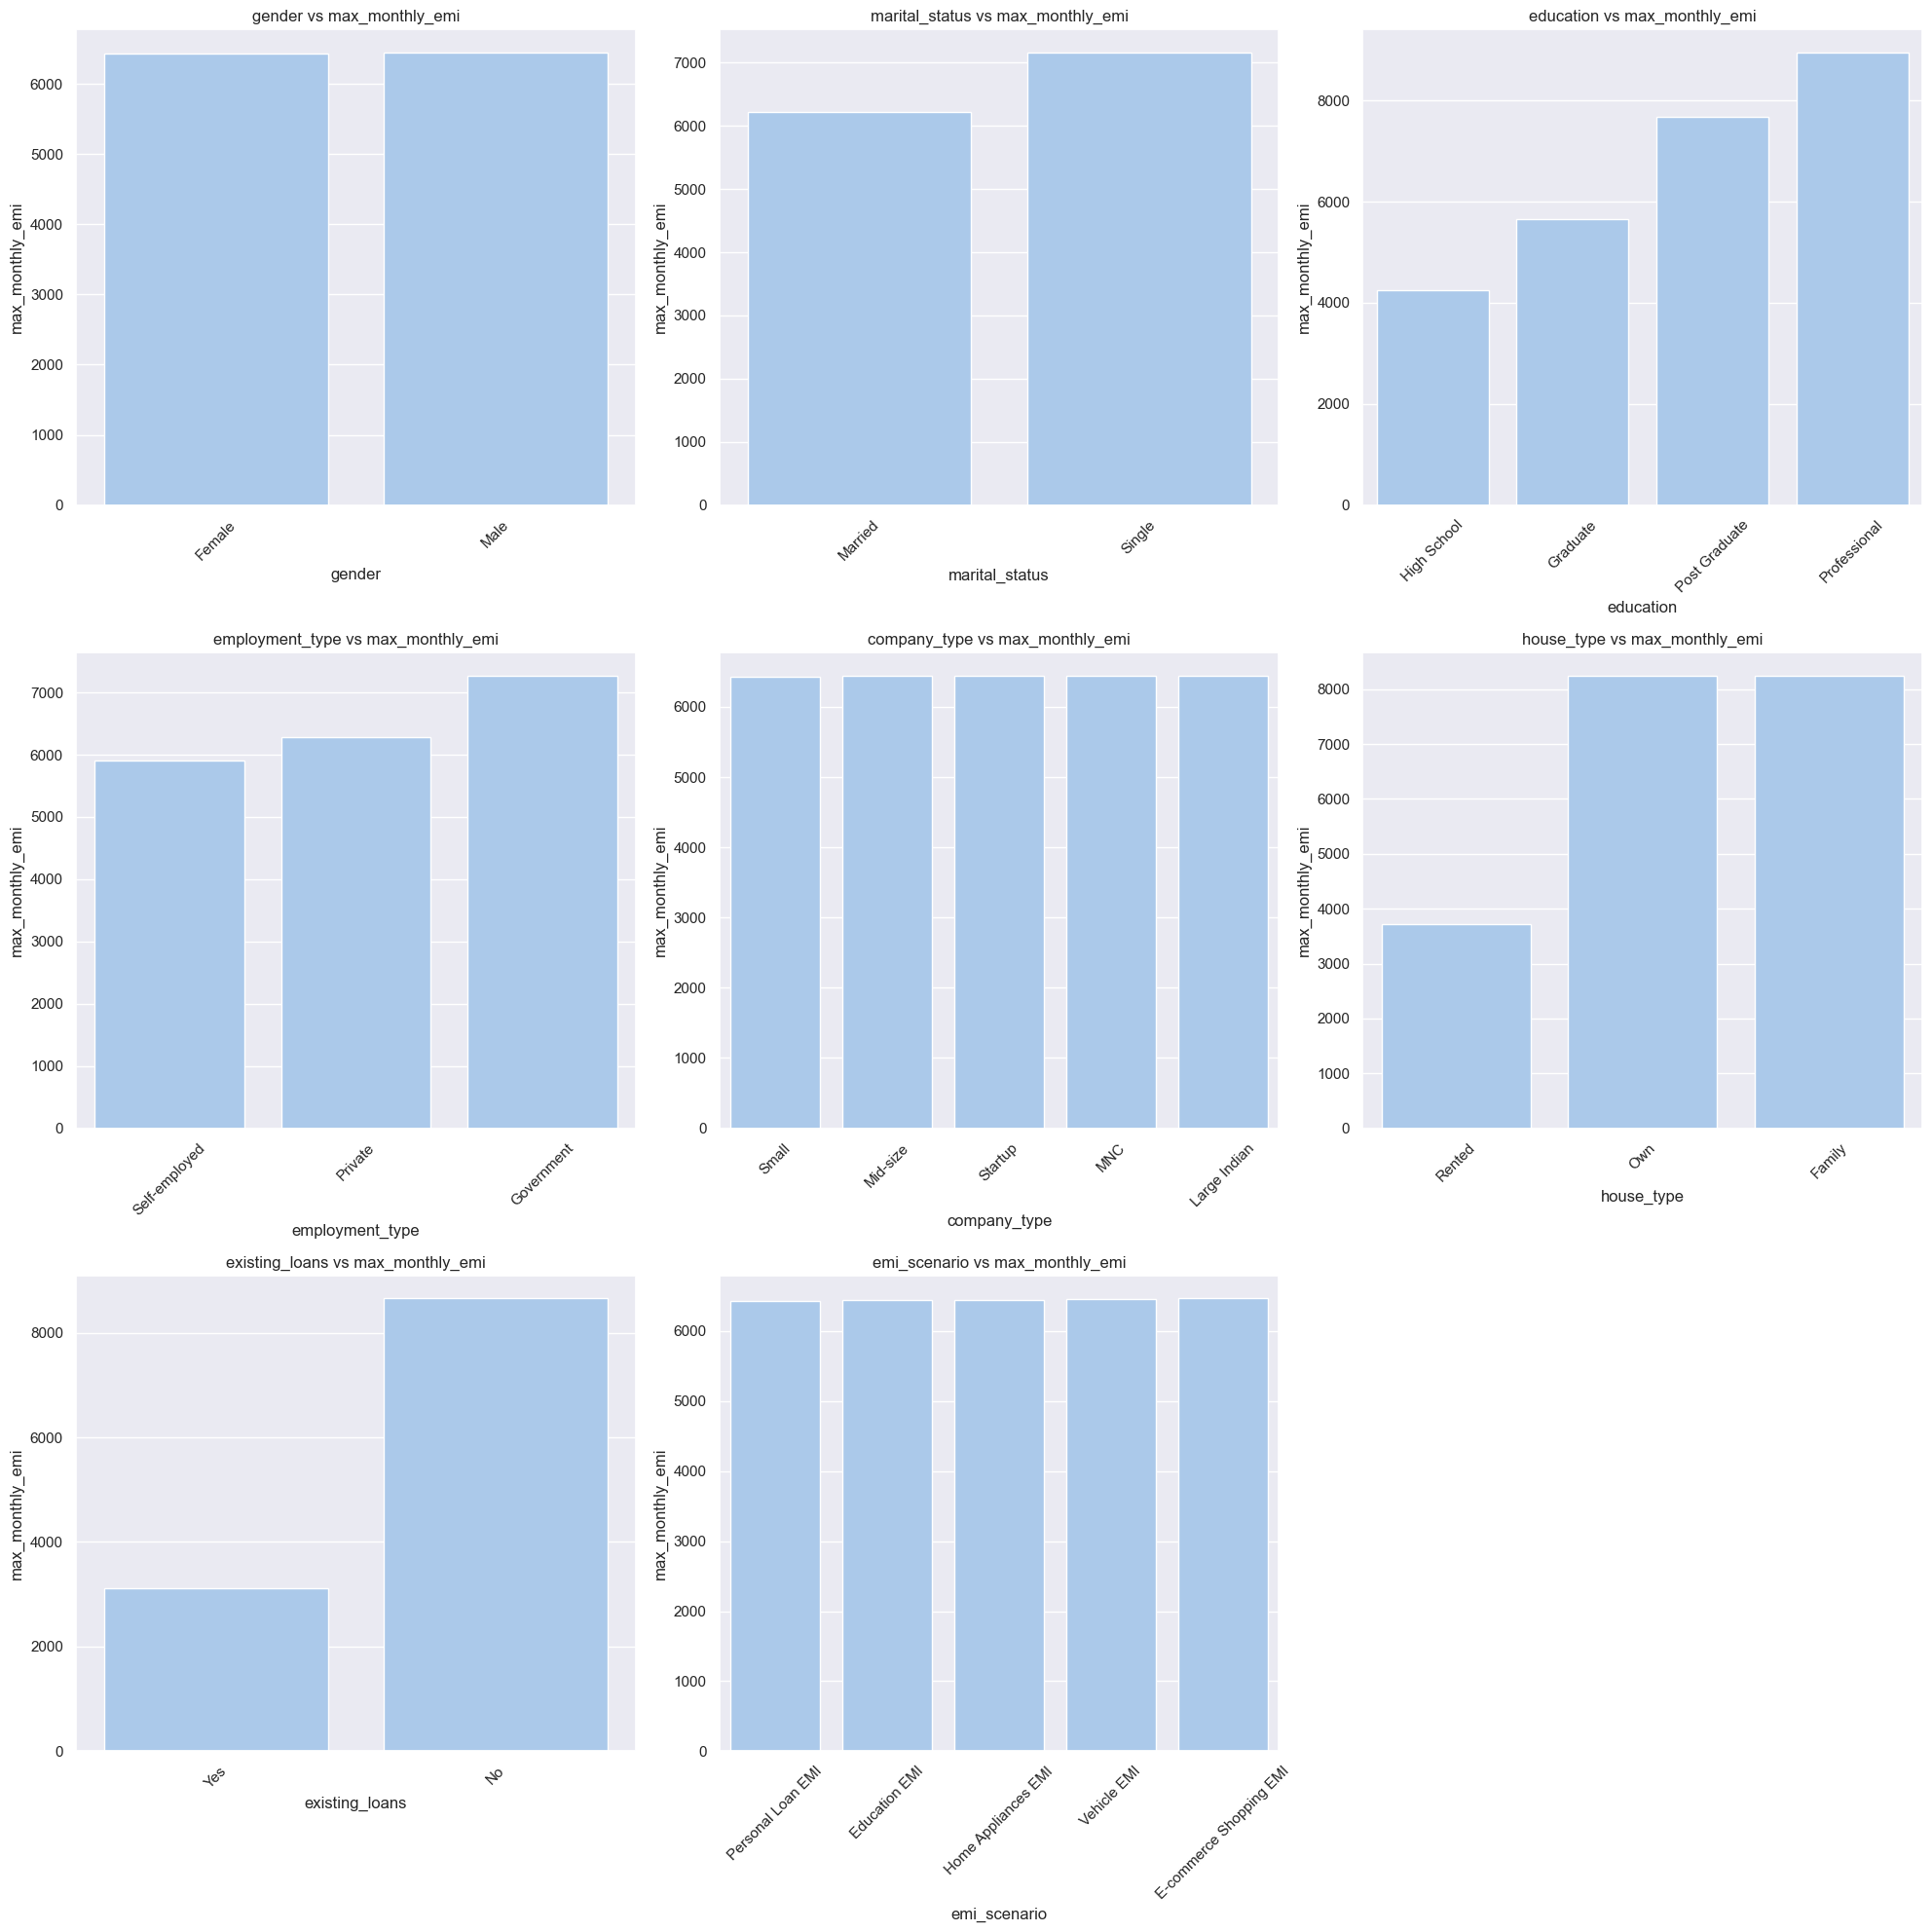

In [349]:
fig, axes = plt.subplots(3, 3, figsize=(20, 20))


axes = axes.flatten()

sns.set_theme(style="darkgrid", palette="pastel")

target = 'max_monthly_emi'

for i, col in enumerate(categorical_cols):

    order = df.groupby(col)[target].mean().sort_values().index  # <-- added line

    sns.barplot(
        data=df,
        x=col,
        y=target,
        estimator="mean",
        order=order,
        errorbar=None,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs {target}")
    axes[i].tick_params(axis='x', rotation=45)

# remove empty plots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

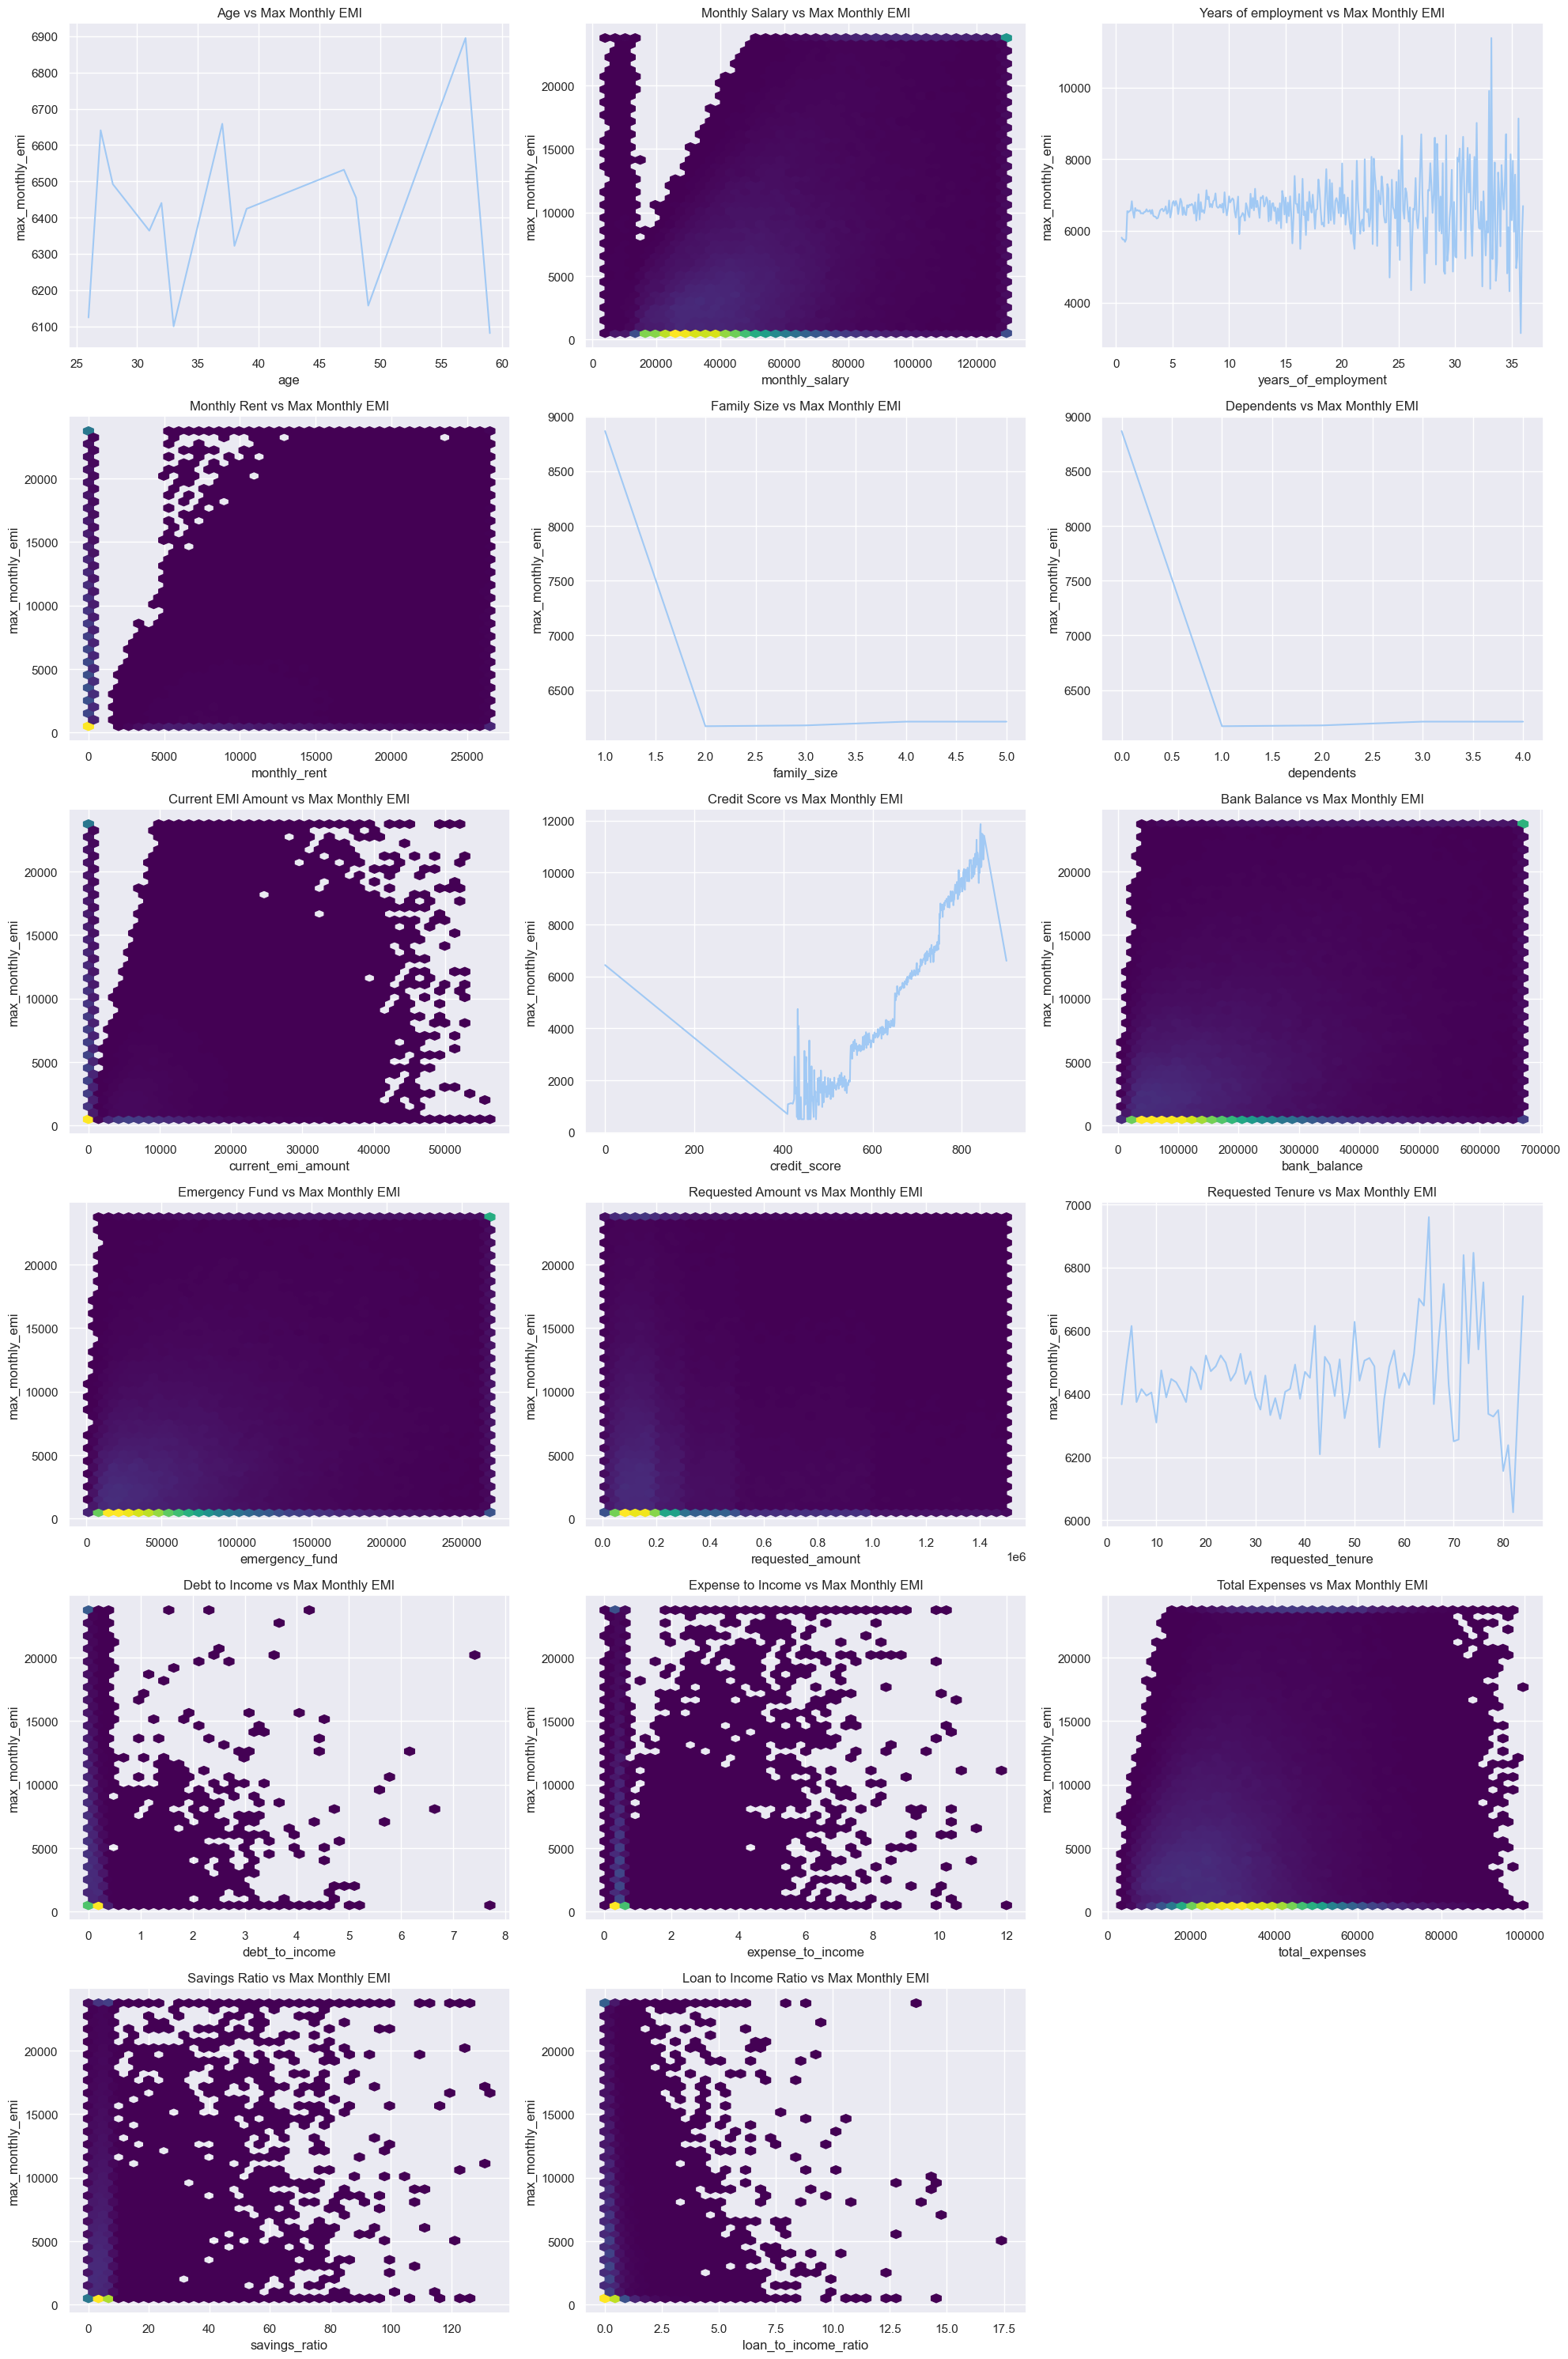

In [350]:
fig, axes = plt.subplots(6, 3, figsize=(20, 30))
axes = axes.flatten()

target = 'max_monthly_emi'

plots = [
    ("age", "line", "Age vs Max Monthly EMI"),
    ("monthly_salary", "scatter", "Monthly Salary vs Max Monthly EMI"),
    ('years_of_employment', 'line','Years of employment vs Max Monthly EMI'),
    ("monthly_rent", "scatter", "Monthly Rent vs Max Monthly EMI"),
    ("family_size", "line", "Family Size vs Max Monthly EMI"),
    ("dependents", "line", "Dependents vs Max Monthly EMI"),
    ("current_emi_amount", "scatter", "Current EMI Amount vs Max Monthly EMI"),
    ("credit_score", "line", "Credit Score vs Max Monthly EMI"),
    ("bank_balance", "scatter", "Bank Balance vs Max Monthly EMI"),
    ("emergency_fund", "scatter", "Emergency Fund vs Max Monthly EMI"),
    ("requested_amount", "scatter", "Requested Amount vs Max Monthly EMI"),
    ("requested_tenure", "line", "Requested Tenure vs Max Monthly EMI"),
    ("debt_to_income", "scatter", "Debt to Income vs Max Monthly EMI"),
    ("expense_to_income", "scatter", "Expense to Income vs Max Monthly EMI"),
    ("total_expenses", "scatter", "Total Expenses vs Max Monthly EMI"),
    ("savings_ratio", "scatter", "Savings Ratio vs Max Monthly EMI"),
    ("loan_to_income_ratio", "scatter", "Loan to Income Ratio vs Max Monthly EMI")
]

for i, (col, kind, title) in enumerate(plots):

    if kind == "scatter":
        axes[i].hexbin(
            df[col],
            df[target],
            gridsize=40,
            cmap="viridis",
            mincnt=1
        )
    else:
        sns.lineplot(
            data=df,
            x=col,
            y=target,
            estimator="mean",
            errorbar=None,
            ax=axes[i]
        )

    axes[i].set_title(title)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target)

# remove unused plots
for j in range(len(plots), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. **Columns not required:** gender, marital_status, age, company_type, emi_scenario
2. **Label encoding:** education, existing loans
3. **One hot:** employment_type, house_type
4. **High importance:** current_emi_amount, credit_score, debt_to_income, monthly_salary, loan_to_income_ratio

5. **Moderate:** expense_to_income, monthly_rent, family_size, dependents, savings_ratio

6. **Low importance:** bank_balance, emergency_fund, requested_amount,
requested_tenure, total_expenses, age


In [351]:
del df['age']
del df['gender']
del df['marital_status']
del df['company_type']
del df['emi_scenario']

# columns with low importance:

# del df['bank_balance']
# del df['emergency_fund']
# del df['requested_amount']
# del df['requested_tenure']
# del df['total_expenses']

del df['college_fees_log']
del df['requested_amount_log']

In [352]:
df.columns

Index(['education', 'monthly_salary', 'employment_type', 'years_of_employment',
       'house_type', 'monthly_rent', 'family_size', 'dependents',
       'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance',
       'emergency_fund', 'requested_amount', 'requested_tenure',
       'emi_eligibility', 'max_monthly_emi', 'debt_to_income',
       'expense_to_income', 'total_expenses', 'savings_ratio',
       'loan_to_income_ratio'],
      dtype='object')

## Encoding the data

In [353]:
education_map = {
    'High School' : 0,
    'Graduate' : 1,
    'Post Graduate' : 2,
    'Professional' : 3
}

existing_loans_map = {
    'No' : 0,
    'Yes' : 1
}
df['education'] = df['education'].map(education_map)
df['existing_loans'] = df['existing_loans'].map(existing_loans_map)

df = pd.get_dummies(
    df,
    columns=['employment_type', 'house_type'],
    drop_first=True,
    dtype='int8'
)

In [354]:
df.head()

,education,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,existing_loans,current_emi_amount,credit_score,bank_balance,...,max_monthly_emi,debt_to_income,expense_to_income,total_expenses,savings_ratio,loan_to_income_ratio,employment_type_Private,employment_type_Self-employed,house_type_Own,house_type_Rented
0,3,82600.0,0.9,20000.0,3,2,1,23700.0,660.0,303200.0,...,500.0,0.286925,0.483051,39900.0,3.670702,0.686037,1,0,0,1
1,1,21500.0,7.0,0.0,2,1,1,4100.0,714.0,92500.0,...,700.0,0.190698,0.479070,15400.0,4.302326,0.313341,1,0,0,0
2,3,86100.0,5.8,0.0,4,3,0,0.0,650.0,671650.0,...,23730.0,0.000000,0.413473,35600.0,7.800813,0.222125,1,0,1,0
3,0,66800.0,2.2,0.0,5,4,0,0.0,685.0,440900.0,...,16170.0,0.000000,0.389222,37400.0,6.600299,0.054830,1,0,1,0
4,3,57300.0,3.4,0.0,4,3,0,0.0,770.0,97300.0,...,500.0,0.000000,0.486911,58600.0,1.698080,0.628272,1,0,0,0


In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392908 entries, 0 to 404799
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   education                      392908 non-null  int64  
 1   monthly_salary                 392908 non-null  float64
 2   years_of_employment            392908 non-null  float64
 3   monthly_rent                   392908 non-null  float64
 4   family_size                    392908 non-null  int64  
 5   dependents                     392908 non-null  int64  
 6   existing_loans                 392908 non-null  int64  
 7   current_emi_amount             392908 non-null  float64
 8   credit_score                   392908 non-null  float64
 9   bank_balance                   392908 non-null  float64
 10  emergency_fund                 392908 non-null  float64
 11  requested_amount               392908 non-null  float64
 12  requested_tenure               3929

## Splitting the data

In [356]:
X = df.drop(['emi_eligibility', 'max_monthly_emi'],axis=1)
y = df['max_monthly_emi']

In [357]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=70)

In [358]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(314326, 22) (78582, 22) (314326,) (78582,)


## Linear Regression

In [359]:
from sklearn.linear_model import LinearRegression #import

linear_model = LinearRegression(fit_intercept=True) #initialise
linear_model.fit(X_train, y_train) #fit - all magic
print(linear_model.predict(X_test))     #predict
print(y_test)

[ 6556.05525333 -1011.88132758  1827.05616511 ...  8048.84549708
 -1015.10654367  -684.52136319]
232913     6244.0
298967      500.0
122808     7280.0
266145    20300.0
34500     12936.0
           ...   
393717     3520.0
378150     4060.0
233397     8120.0
339847      500.0
25718       500.0
Name: max_monthly_emi, Length: 78582, dtype: float64


In [360]:
linear_model.score(X_test, y_test)

0.7836357554961938

In [361]:
from sklearn.model_selection import cross_val_score
cross_val_linear_model=cross_val_score(linear_model,X_train,y_train,cv=10).mean()
cross_val_linear_model

np.float64(0.7777815242569786)

In [362]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# predictions
y_pred = linear_model.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2161.991267331327
MSE: 9604867.043846665
RMSE: 3099.171993266373
R2 Score: 0.7836357554961938


## Random forest regression

In [363]:
from sklearn.ensemble import RandomForestRegressor

In [364]:
max_depth=[2,4,8,10,11,12,13,15,18,20]
cross_val_rf=[]

for d in max_depth:
  rf_regressor=RandomForestRegressor(max_depth=d, random_state=0)
  rf_regressor.fit(X_train,y_train)
  print("Depth : ", d, "cross_val_score : ", cross_val_score(rf_regressor,X_train,y_train,cv = 5).mean())
  cross_val_rf.append(cross_val_score(rf_regressor,X_train,y_train,cv = 5).mean())

Depth :  2 cross_val_score :  0.43410378188351195
Depth :  4 cross_val_score :  0.670349444743956
Depth :  8 cross_val_score :  0.908265001968396
Depth :  10 cross_val_score :  0.946728474602882
Depth :  11 cross_val_score :  0.9573569304638999
Depth :  12 cross_val_score :  0.9650368561572036


KeyboardInterrupt: 

In [365]:
rf_regressor=RandomForestRegressor(max_depth=12, random_state=0)
rf_regressor.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [366]:
# predictions
y_pred = rf_regressor.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 698.579725868601
MSE: 1508698.0678811797
RMSE: 1228.2907098407852
R2 Score: 0.9660142804526806


## XGBoost regressor

In [369]:
from xgboost import XGBRegressor

In [371]:
max_depth=[2,4,8,10,11,12,13,15,18,20]
cross_val_xgb=[]

for d in max_depth:
  xgb_regressor=XGBRegressor(max_depth=d, random_state=0)
  rf_regressor.fit(X_train,y_train)
  print("Depth : ", d, "cross_val_score : ", cross_val_score(xgb_regressor,X_train,y_train,cv = 5).mean())
  cross_val_xgb.append(cross_val_score(xgb_regressor,X_train,y_train,cv = 5).mean())

Depth :  2 cross_val_score :  0.8995256722179029
Depth :  4 cross_val_score :  0.9593032692918229
Depth :  8 cross_val_score :  0.9781766988969753
Depth :  10 cross_val_score :  0.97998855209524
Depth :  11 cross_val_score :  0.980080494296647


KeyboardInterrupt: 

In [372]:
xgb_regressor = XGBRegressor(
      max_depth=8,
      random_state=42
  )

xgb_regressor.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [373]:
# predictions
y_pred = xgb_regressor.predict(X_test)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 523.740752697531
MSE: 922692.9600987483
RMSE: 960.5690813776739
R2 Score: 0.9792149371449506


## MLFlow

In [2]:
import mlflow

In [375]:
# Ensure any active MLflow run is ended before starting a new one
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="RandomForest_Regressor"):

    model = xgb_regressor # Corrected from 'rf' to 'rf_regressor'
    model.fit(X_train, y_train) # Corrected from '_reg' variables

    y_pred = model.predict(X_test) # Corrected from '_reg' variables

    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Corrected: removed 'squared=False'
    r2 = r2_score(y_test, y_pred) # Corrected from '_reg' variables

    mlflow.log_param("model", "XGBoost Regressor")

    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2_score", r2)

    mlflow.sklearn.log_model(model, "model")

2026/03/12 12:43:26 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/03/12 12:43:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

In [1]:
mlflow.log_param("max_depth", model.max_depth)

NameError: name 'mlflow' is not defined

In [ ]:
mlflow.log_metric()
mlflow.sklearn.log_model()

In [377]:
import matplotlib.pyplot as plt

plt.savefig("feature_importance.png")

mlflow.log_artifact("feature_importance.png")

<Figure size 640x480 with 0 Axes>

## Comparison table

In [379]:
results = []

models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_regressor,
    "XGBoost": xgb_regressor
}

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

In [380]:
comparison_table_rg = pd.DataFrame(results)
comparison_table_rg

,Model,RMSE,MAE,R2 Score
0,Linear Regression,3099.171993,2161.991267,0.783636
1,Random Forest,1228.290710,698.579726,0.966014
2,XGBoost,960.569081,523.740753,0.979215


In [ ]:
comparison_table_rg.sort_values("RMSE")

## Model selection

In [381]:
best_model = xgb_regressor

feature_columns = X_train.columns


importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(f"Feature Importances for {model.__class__.__name__}:")
print(feature_importance)
print("-" * 30) # Separator

Feature Importances for XGBRegressor:
                          Feature  Importance
6                  existing_loans    0.413594
21              house_type_Rented    0.368012
1                  monthly_salary    0.093352
15                 total_expenses    0.039228
14              expense_to_income    0.020012
8                    credit_score    0.011218
9                    bank_balance    0.010362
13                 debt_to_income    0.009477
18        employment_type_Private    0.007690
16                  savings_ratio    0.006893
19  employment_type_Self-employed    0.005997
3                    monthly_rent    0.005971
2             years_of_employment    0.002781
4                     family_size    0.001189
7              current_emi_amount    0.000813
10                 emergency_fund    0.000743
17           loan_to_income_ratio    0.000598
12               requested_tenure    0.000553
0                       education    0.000550
11               requested_amount    0.000

In [382]:
top_10_features = [
    'existing_loans',
    'house_type_Rented',
    'monthly_salary',
    'total_expenses',
    'expense_to_income',
    'credit_score',
    'bank_balance',
    'debt_to_income',
    'employment_type_Private',
    'savings_ratio'
]

In [383]:
X_top10 = df[top_10_features]
y = df['max_monthly_emi']

In [391]:
X_top10.columns

Index(['existing_loans', 'house_type_Rented', 'monthly_salary',
       'total_expenses', 'expense_to_income', 'credit_score', 'bank_balance',
       'debt_to_income', 'employment_type_Private', 'savings_ratio'],
      dtype='object')

In [384]:
X_train, X_test, y_train, y_test = train_test_split(
    X_top10, y, test_size=0.2, random_state=42
)

In [385]:
linear_model = LinearRegression()
rf_regressor = RandomForestRegressor(random_state=42)
xgb_regressor = XGBRegressor(random_state=42)

In [386]:
results_top10 = []

models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_regressor,
    "XGBoost": xgb_regressor
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results_top10.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

In [387]:
results_top10_df = pd.DataFrame(results_top10)
results_top10_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,3506.996712,2590.376770,0.723371
1,Random Forest,1326.998162,734.720868,0.960393
2,XGBoost,1420.715571,915.416942,0.954602


In [389]:
best_reg = rf_regressor

In [393]:
import joblib

In [394]:
joblib.dump(best_reg, "emi_regressor.pkl")

['emi_regressor.pkl']